In [147]:
import pandas as pd   #Reads and handles dataset.
import numpy as np    #Numerical operations.
import re             #Text cleaning using regular expressions
import nltk           #NLP toolkit for text preprocessing.

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [148]:
#loads the customer review dataset into a dataframe.

df = pd.read_excel("Sentiment Analysis Dataset.xlsx")

print(df.head())
print(df.shape)

                                     title  rating  \
0                         Horrible product       1   
1  Camera quality is not like 48 megapixel       3   
2                                  Overall       4   
3                         A big no from me       1   
4            Put your money somewhere else       1   

                                                body  
0  Very disappointed with the overall performance...  
1                              Camera quality is low  
2  Got the mobile on the launch date,Battery must...  
3  1. It doesn't work with 5.0GHz WiFi frequency....  
4  Not worth buying....faulty software, poor disp...  
(1440, 3)


In [116]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None


In [117]:
print(df.isnull().sum())  #Check for missing Values

title     0
rating    0
body      0
dtype: int64


In [118]:
print(df.describe())     #Statistical Summary


            rating
count  1440.000000
mean      3.173611
std       1.584453
min       1.000000
25%       1.000000
50%       4.000000
75%       5.000000
max       5.000000


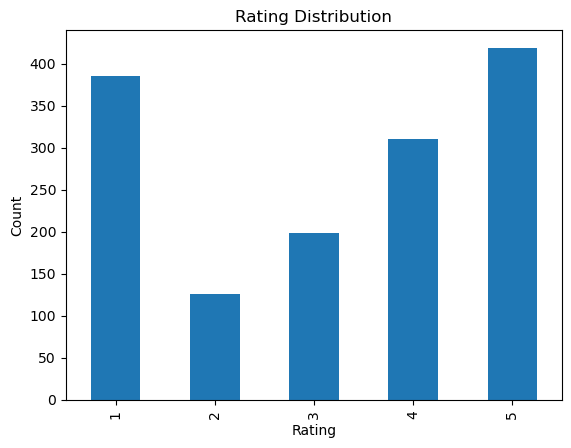

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

In [149]:
#Rating Distribution

import matplotlib.pyplot as plt

df['rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

df['rating'].value_counts()

In [150]:
#Create Sentiment Label

def sentiment_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['rating'].apply(sentiment_label)

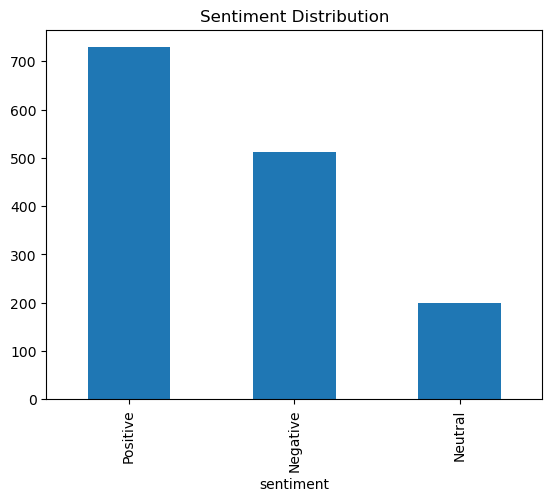

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

In [151]:
#Sentiment Distribution

df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")
plt.show()

df['sentiment'].value_counts()

In [152]:
df['review'] = df['title'] + " " + df['body']

In [153]:
#Review Length Analysis

df['review_length'] = df['review'].apply(len)

print(df['review_length'].describe())

count    1440.000000
mean      333.381944
std       229.116704
min         9.000000
25%       198.000000
50%       277.000000
75%       395.000000
max      2536.000000
Name: review_length, dtype: float64


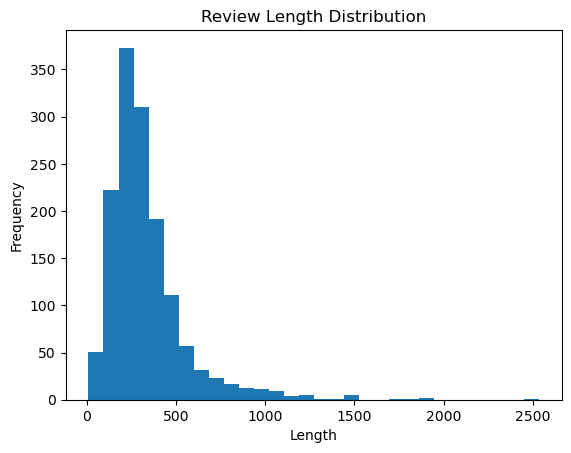

In [154]:
#Review Length Histogram

plt.hist(df['review_length'], bins=30)

plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


In [155]:
# Most Frequent Words

from collections import Counter
text = " ".join(df['review'].astype(str))
words = text.lower().split()
common_words = Counter(words).most_common(20)
print(common_words)

[('is', 3159), ('the', 2202), ('and', 1715), ('phone', 1507), ('this', 1453), ('for', 1442), ('not', 1352), ('to', 1329), ('i', 1242), ('a', 1200), ('good', 1091), ('it', 1064), ('in', 1042), ('of', 849), ('camera', 836), ('with', 766), ('battery', 723), ('very', 716), ('but', 692), ('samsung', 663)]


In [156]:
#Word Cloud

!pip install wordcloud

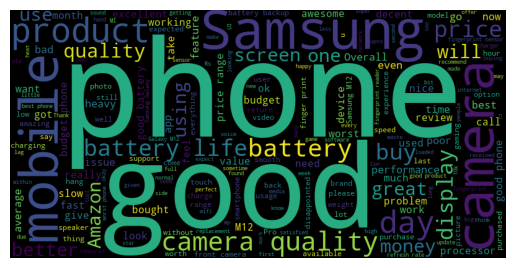

In [157]:
from wordcloud import WordCloud

text = " ".join(df['review'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

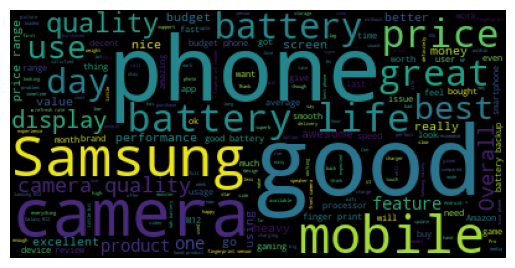

In [159]:
#Positive Word Cloud

positive_text = " ".join(
    df[df['sentiment']=="Positive"]['review']
)

wordcloud = WordCloud().generate(positive_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

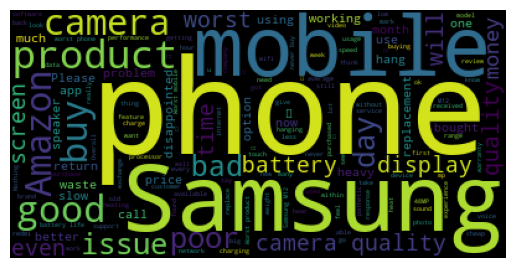

In [160]:
#Negative WOrd Cloud

negative_text = " ".join(
    df[df['sentiment']=="Negative"]['review']
)

wordcloud = WordCloud().generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [161]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

df = df.drop_duplicates()

Duplicate Records : 0


In [162]:
# Creates additional Word Count Feature

df['word_count'] = df['review'].apply(
    lambda x: len(str(x).split())
)

df[['review','word_count']].head()

,review,word_count
0,Horrible product Very disappointed with the ov...,10
1,Camera quality is not like 48 megapixel Camera...,11
2,"Overall Got the mobile on the launch date,Batt...",67
3,A big no from me 1. It doesn't work with 5.0GH...,72
4,Put your money somewhere else Not worth buying...,34


In [163]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kiran_Nishad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Kiran_Nishad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Kiran_Nishad\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [164]:
# Text Cleaning Function

stop_words = set(stopwords.words('english'))

# Keep 'not' because it affects sentiment
stop_words.discard('not')

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    # Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [165]:
# Apply Cleaning Function

df['clean_review'] = df['review'].apply(clean_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,Horrible product Very disappointed with the ov...,horrible product disappointed overall performa...
1,Camera quality is not like 48 megapixel Camera...,camera quality not like megapixel camera quali...
2,"Overall Got the mobile on the launch date,Batt...",overall got mobile launch date battery must ap...
3,A big no from me 1. It doesn't work with 5.0GH...,big work ghz wifi frequency ghz old school cam...
4,Put your money somewhere else Not worth buying...,put money somewhere else not worth buying faul...


In [166]:
# Compare Original and Cleaned Review

print("Original Review:")
print(df['review'].iloc[0])

print("\nClean Review:")
print(df['clean_review'].iloc[0])

Original Review:
Horrible product Very disappointed with the overall performance from Samsung

Clean Review:
horrible product disappointed overall performance samsung


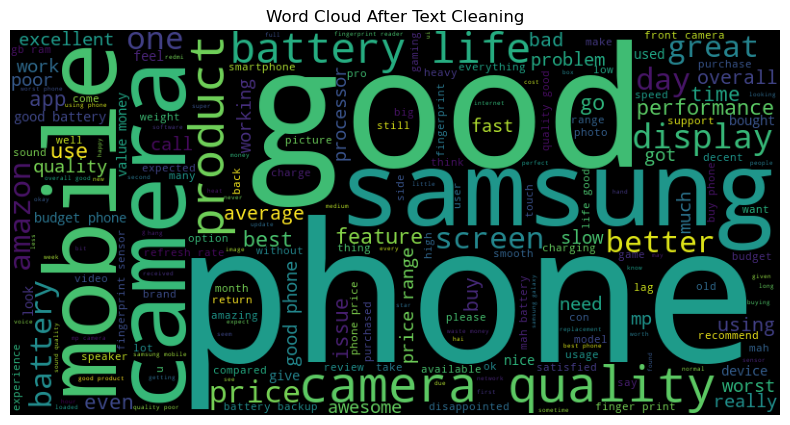

In [167]:
# Word Cloud After Cleaning

from wordcloud import WordCloud

clean_text_data = " ".join(df['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(clean_text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud After Text Cleaning")
plt.show()

In [168]:
# TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

print("TF-IDF Shape :", X.shape)

TF-IDF Shape : (1440, 4841)


In [169]:
df.head()

,title,rating,body,sentiment,review,review_length,word_count,clean_review
0,Horrible product,1,Very disappointed with the overall performance...,Negative,Horrible product Very disappointed with the ov...,76,10,horrible product disappointed overall performa...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,Camera quality is not like 48 megapixel Camera...,61,11,camera quality not like megapixel camera quali...
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,"Overall Got the mobile on the launch date,Batt...",411,67,overall got mobile launch date battery must ap...
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,A big no from me 1. It doesn't work with 5.0GH...,394,72,big work ghz wifi frequency ghz old school cam...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,Put your money somewhere else Not worth buying...,209,34,put money somewhere else not worth buying faul...


In [170]:
# Target Variable

y = df['sentiment']

print(y.head())

0    Negative
1     Neutral
2    Positive
3    Negative
4    Negative
Name: sentiment, dtype: object


In [141]:
# Display Features Created by TF-IDF

feature_names = tfidf.get_feature_names_out()

print("Total Features :", len(feature_names))

print("\nSample Features:")
print(feature_names[:50])

Total Features : 4841

Sample Features:
['aanel' 'aap' 'aaya' 'ab' 'abhi' 'abide' 'ability' 'able' 'abruptly'
 'absence' 'absentresolution' 'absolute' 'absolutely' 'abt' 'accept'
 'acceptable' 'acceptance' 'accepted' 'accepting' 'accepts' 'accesories'
 'access' 'accessible' 'accessiblty' 'accessory' 'accezsbiljty' 'accha'
 'acchi' 'accidentally' 'accidently' 'accommodated' 'accomodate'
 'according' 'accordingly' 'accurate' 'acha' 'achcha' 'achchaa' 'achha'
 'acknowledge' 'acko' 'acquired' 'across' 'action' 'activate' 'activated'
 'activating' 'active' 'activity' 'actor']


In [142]:
print("\nLast 50 Features:")
print(feature_names[-50:])


Last 50 Features:
['wrapped' 'wright' 'write' 'writing' 'written' 'writting' 'wrong'
 'wrongfully' 'wrongly' 'wrost' 'wrote' 'wt' 'wtf' 'wth' 'wuse' 'www'
 'xiaomi' 'xioami' 'xl' 'xp' 'xperia' 'ya' 'yaa' 'ye' 'yea' 'yeah' 'year'
 'yearend' 'yeh' 'yellowish' 'yes' 'yesterday' 'yesterdy' 'yet' 'yhe' 'yo'
 'yor' 'youi' 'young' 'youth' 'youtube' 'youtubers' 'yr' 'ysers'
 'zabardsti' 'zappy' 'zeiss' 'zero' 'zoom' 'zooming']


In [177]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder



# Create TF-IDF features
X = tfidf_vectorizer.fit_transform(df['clean_review'])

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])

sentiment_mapping = dict(
    zip(label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_))
)

print(f"Sentiment Label Mapping: {sentiment_mapping}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Sentiment Label Mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
Training data shape: (1152, 6962)
Testing data shape: (288, 6962)
Logistic Regression model trained successfully!


In [178]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [179]:
y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.82      0.81       102
     Neutral       0.50      0.03      0.05        40
    Positive       0.77      0.95      0.85       146

    accuracy                           0.78       288
   macro avg       0.69      0.60      0.57       288
weighted avg       0.74      0.78      0.72       288



In [182]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.01,0.1,1,10,100]
}

grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_logistic_model = grid_search.best_estimator_

print(grid_search.best_params_)

{'C': 1}


In [183]:
y_pred_best = best_logistic_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.76      0.82      0.79       102
     Neutral       0.32      0.28      0.30        40
    Positive       0.86      0.84      0.85       146

    accuracy                           0.76       288
   macro avg       0.65      0.65      0.65       288
weighted avg       0.75      0.76      0.75       288



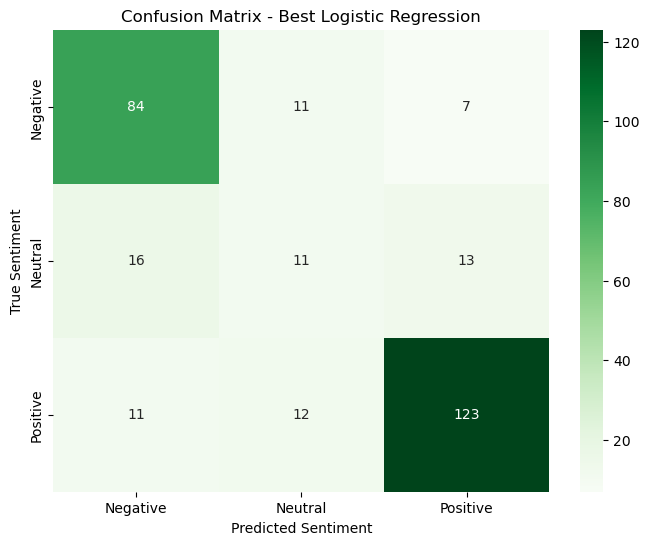

In [184]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix - Best Logistic Regression')

plt.show()

In [185]:
import pickle

with open("model.pkl","wb") as f:
    pickle.dump(best_logistic_model,f)

with open("tfidf.pkl","wb") as f:
    pickle.dump(tfidf_vectorizer,f)

with open("label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder,f)

print("Files saved successfully.")

Files saved successfully.


In [186]:
reviews = [
    "Excellent camera quality and battery backup.",
    "Very disappointed with the performance.",
    "The phone arrived yesterday.",
    "The product is average."
]

reviews_tfidf = tfidf_vectorizer.transform(reviews)

predictions = best_logistic_model.predict(reviews_tfidf)

for review, pred in zip(reviews, predictions):
    sentiment = label_encoder.inverse_transform([pred])[0]
    print(review)
    print("Predicted:", sentiment)
    print()

Excellent camera quality and battery backup.
Predicted: Positive

Very disappointed with the performance.
Predicted: Negative

The phone arrived yesterday.
Predicted: Negative

The product is average.
Predicted: Neutral



<h2>Naive Bayes

In [57]:
from sklearn.naive_bayes import MultinomialNB

naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)
print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


Naive Bayes Model Accuracy: 0.74

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.67      0.75       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.69      0.99      0.81       146

    accuracy                           0.74       288
   macro avg       0.52      0.55      0.52       288
weighted avg       0.65      0.74      0.68       288



C:\Users\AMIT PATEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AMIT PATEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AMIT PATEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

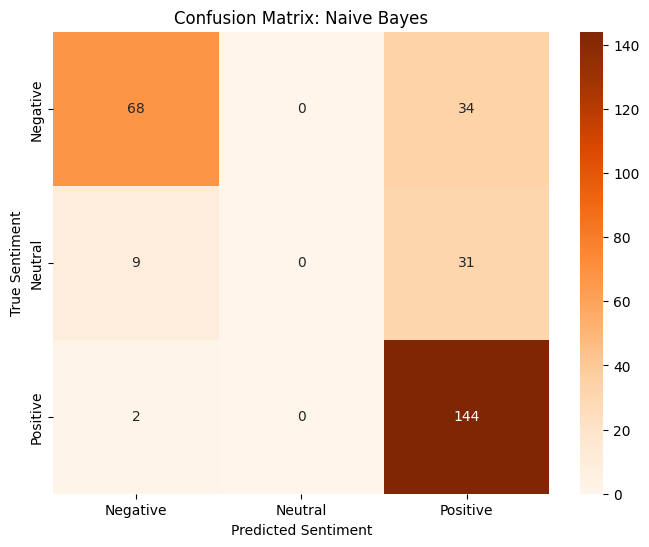

In [58]:
y_pred_nb = naive_bayes_model.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Model Accuracy: {accuracy_nb:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix: Naive Bayes')
plt.show()

<h1>Support Vector Machine

In [37]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
print("Support Vector Machine model trained successfully!")

Support Vector Machine model trained successfully!


Support Vector Machine Model Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.83      0.80       102
     Neutral       0.58      0.17      0.27        40
    Positive       0.81      0.91      0.86       146

    accuracy                           0.78       288
   macro avg       0.72      0.64      0.64       288
weighted avg       0.76      0.78      0.75       288



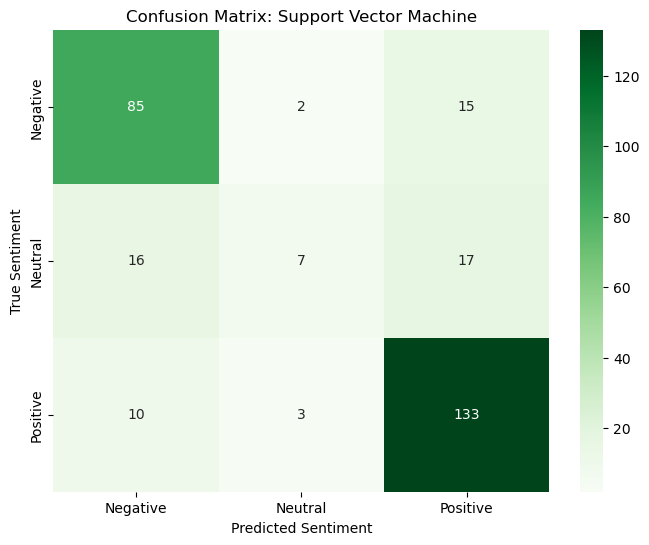

In [38]:
y_pred_svm = svm_model.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Support Vector Machine Model Accuracy: {accuracy_svm:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix: Support Vector Machine')
plt.show()

<h1>K-Nearest Neighbors

In [61]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=30)
knn_model.fit(X_train, y_train)
print("K-Nearest Neighbors model trained successfully!")

K-Nearest Neighbors model trained successfully!


K-Nearest Neighbors Model Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79       102
     Neutral       0.50      0.03      0.05        40
    Positive       0.75      0.93      0.83       146

    accuracy                           0.76       288
   macro avg       0.68      0.59      0.56       288
weighted avg       0.73      0.76      0.71       288



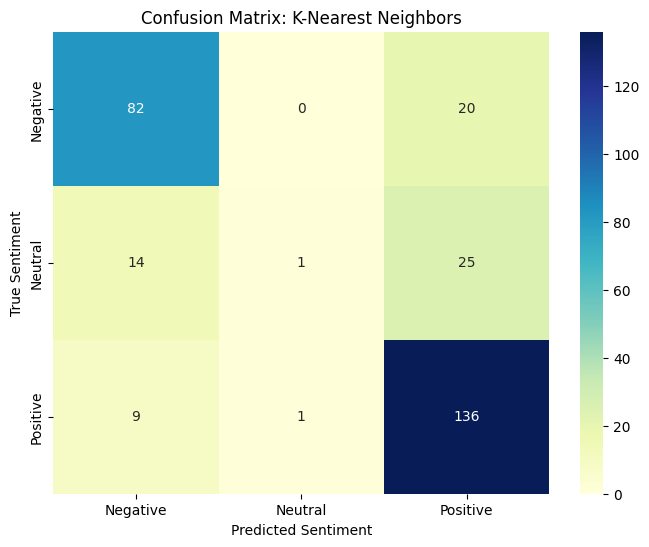

In [62]:
y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"K-Nearest Neighbors Model Accuracy: {accuracy_knn:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix: K-Nearest Neighbors')
plt.show()

<h1>Random Forest Classifier

In [63]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)
print("Random Forest Classifier model trained successfully!")

Random Forest Classifier model trained successfully!


Random Forest Classifier Model Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.80      0.78       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.74      0.92      0.82       146

    accuracy                           0.75       288
   macro avg       0.50      0.57      0.53       288
weighted avg       0.65      0.75      0.69       288



C:\Users\AMIT PATEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AMIT PATEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AMIT PATEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

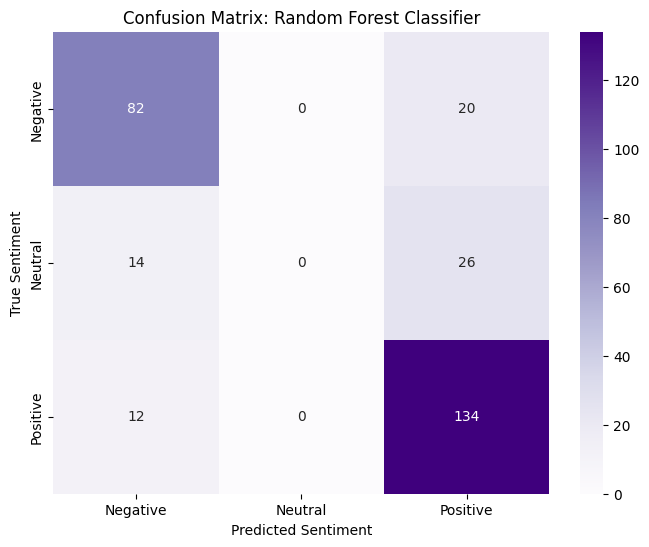

In [64]:
y_pred_rf = random_forest_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Model Accuracy: {accuracy_rf:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix: Random Forest Classifier')
plt.show()

In [39]:
# Install imblearn if not already installed
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

print("Applying SMOTE to handle class imbalance...")
# Applying SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training data shape: {X_train.shape}")
print(f"Training data shape after SMOTE: {X_train_smote.shape}")
print(f"Class distribution after SMOTE: {pd.Series(y_train_smote).value_counts()}")

Applying SMOTE to handle class imbalance...
Original training data shape: (1152, 4841)
Training data shape after SMOTE: (1749, 4841)
Class distribution after SMOTE: 2    583
0    583
1    583
Name: count, dtype: int64


In [41]:
print("Performing Hyperparameter Tuning with GridSearchCV and Cross-Validation for SVM...")

# Define the parameter grid for SVM
param_grid = {'C': [0.1, 1, 10],'kernel': ['linear', 'rbf'],'gamma': ['scale', 'auto']}

# Initialize GridSearchCV using the balanced training data (X_train_smote, y_train_smote)
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)
grid_search.fit(X_train_smote, y_train_smote)

print("GridSearchCV completed!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1-macro score: {grid_search.best_score_:.2f}")

# Get the best model
best_svm_model = grid_search.best_estimator_

Performing Hyperparameter Tuning with GridSearchCV and Cross-Validation for SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV completed!
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation F1-macro score: 0.92


Evaluating the Best SVM Model on the test set...
Best SVM Model Accuracy (after tuning & SMOTE): 0.78

Classification Report (Best SVM Model):
              precision    recall  f1-score   support

    Negative       0.77      0.85      0.81       102
     Neutral       0.75      0.07      0.14        40
    Positive       0.80      0.93      0.86       146

    accuracy                           0.78       288
   macro avg       0.77      0.62      0.60       288
weighted avg       0.78      0.78      0.74       288



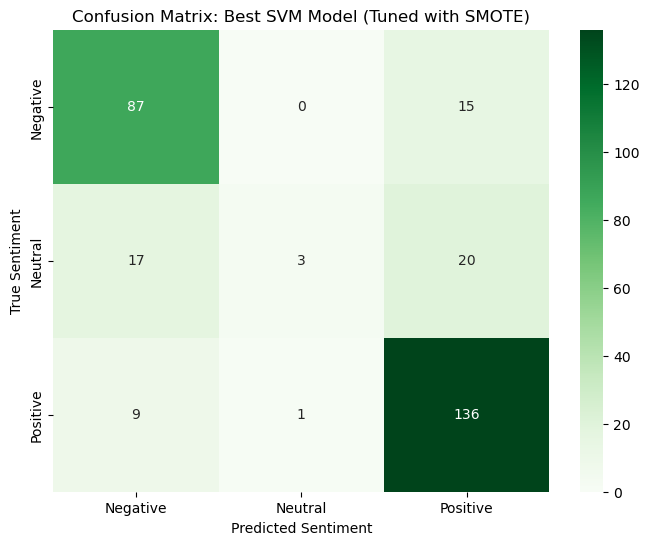

In [42]:
print("Evaluating the Best SVM Model on the test set...")

y_pred_best_svm = best_svm_model.predict(X_test)

accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)
print(f"Best SVM Model Accuracy (after tuning & SMOTE): {accuracy_best_svm:.2f}")

print("\nClassification Report (Best SVM Model):")
print(classification_report(y_test, y_pred_best_svm, target_names=label_encoder.classes_))

cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix: Best SVM Model (Tuned with SMOTE)')
plt.show()

the overall accuracy remained at 0.78 for the best SVM model, even after SMOTE and hyperparameter tuning.t

In [68]:
print(pd.Series(y_train_smote).value_counts())

2    583
0    583
1    583
Name: count, dtype: int64


In [72]:
import sklearn
import numpy
import pandas

print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)

scikit-learn: 1.5.2
numpy: 2.2.0
pandas: 2.2.3
